   Row ID        Order ID Order Date Ship Date       Ship Mode Customer ID  \
0   21896   ID-2012-71858   1/2/2012  7/2/2012  Standard Class    CP-12085   
1    4323  MX-2012-154459   1/2/2012  6/2/2012  Standard Class    JF-15190   
2    2829  MX-2012-114461   1/2/2012  5/2/2012  Standard Class    RM-19375   
3    2828  MX-2012-114461   1/2/2012  5/2/2012  Standard Class    RM-19375   
4    6762  MX-2012-151904   1/2/2012  3/2/2012     First Class    DJ-13420   

    Customer Name    Segment           City      State  ...       Product ID  \
0  Cathy Prescott  Corporate        Jakarta    Jakarta  ...  TEC-PH-10003784   
1    Jamie Frazer   Consumer       Santiago   Santiago  ...  TEC-PH-10002102   
2   Raymond Messe   Consumer      Escuintla  Escuintla  ...  TEC-AC-10002760   
3   Raymond Messe   Consumer      Escuintla  Escuintla  ...  FUR-CH-10001423   
4       Denny Joy  Corporate  Villa Canales  Guatemala  ...  OFF-PA-10003571   

          Category Sub-Category                   

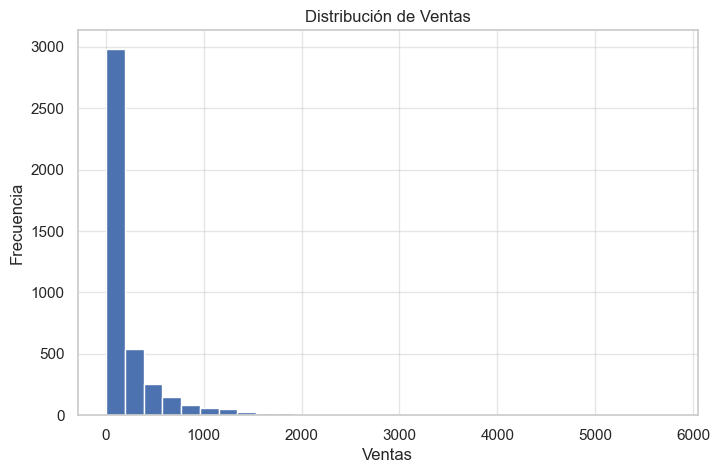

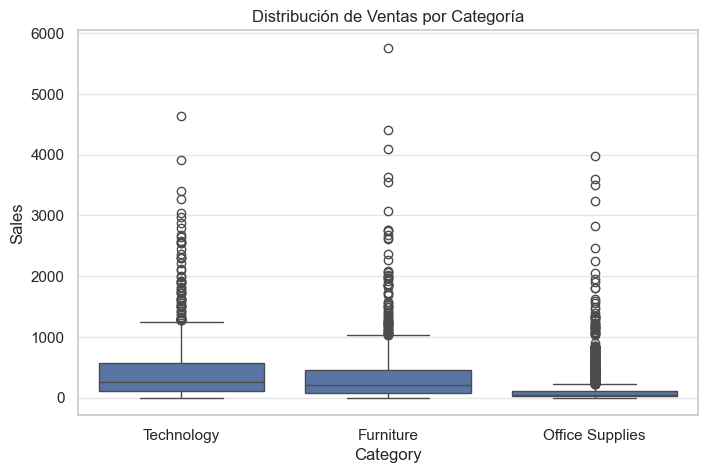

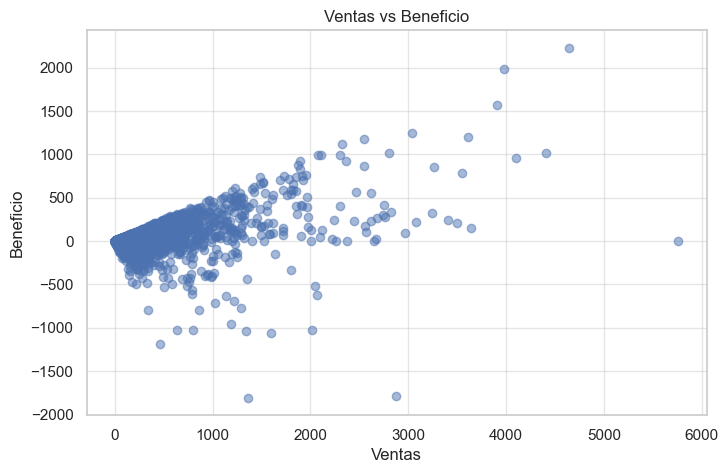

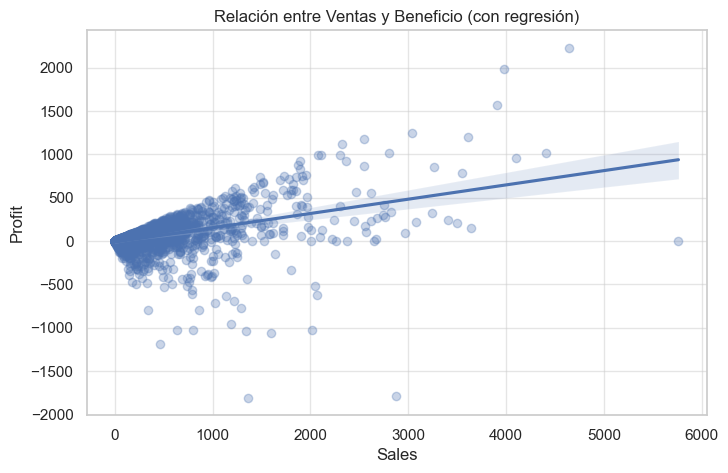

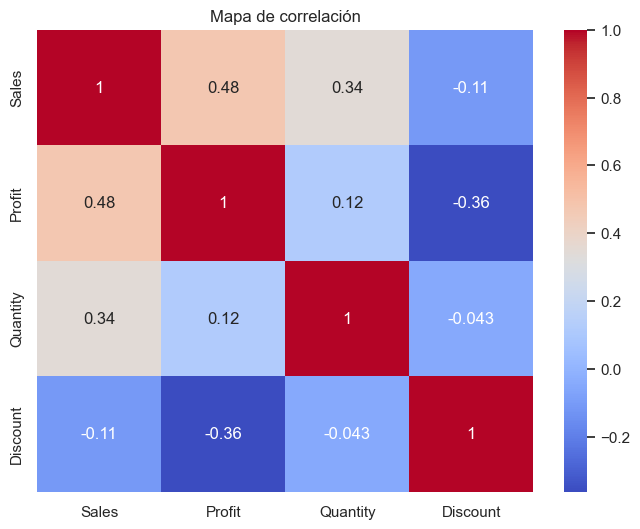

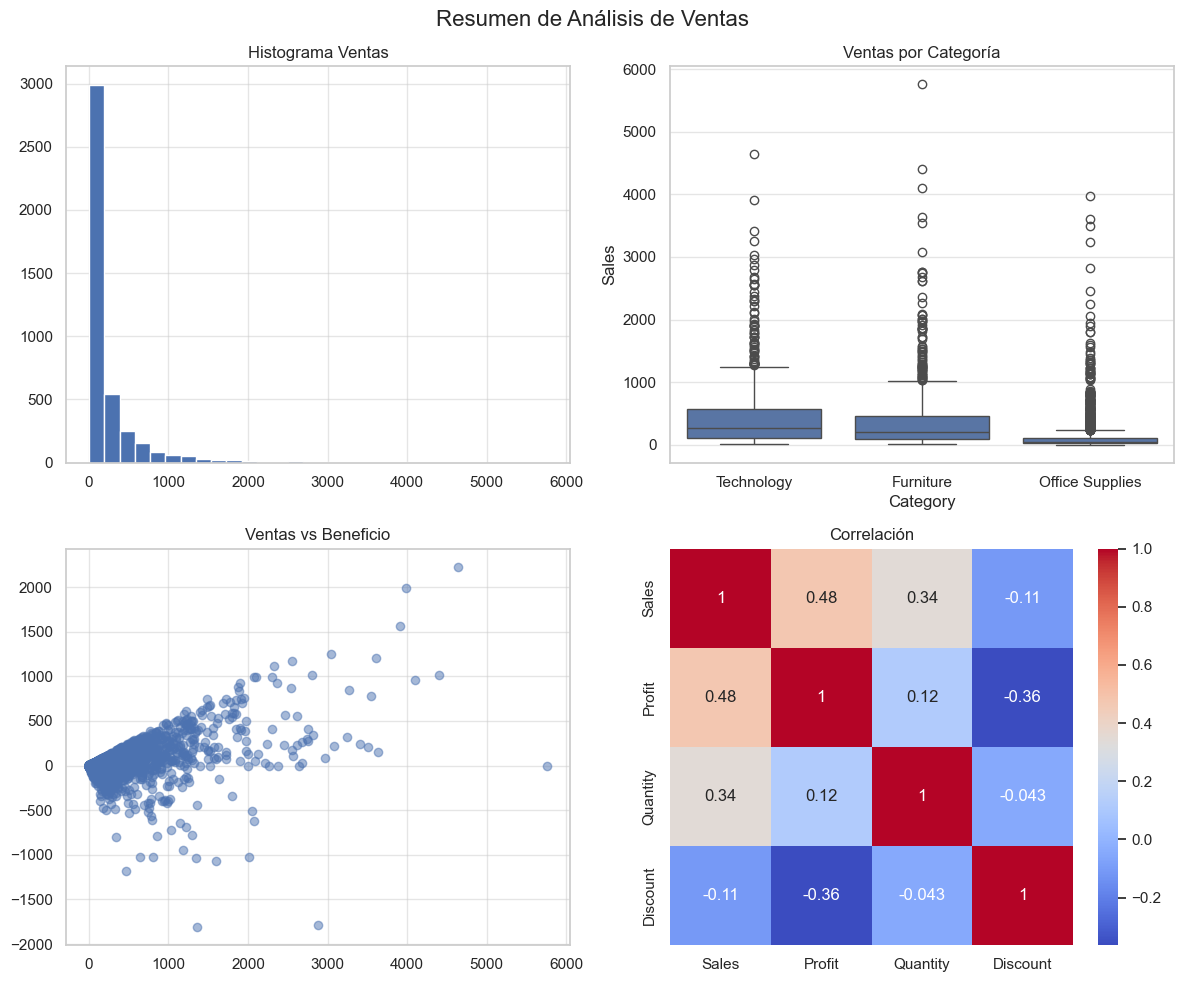

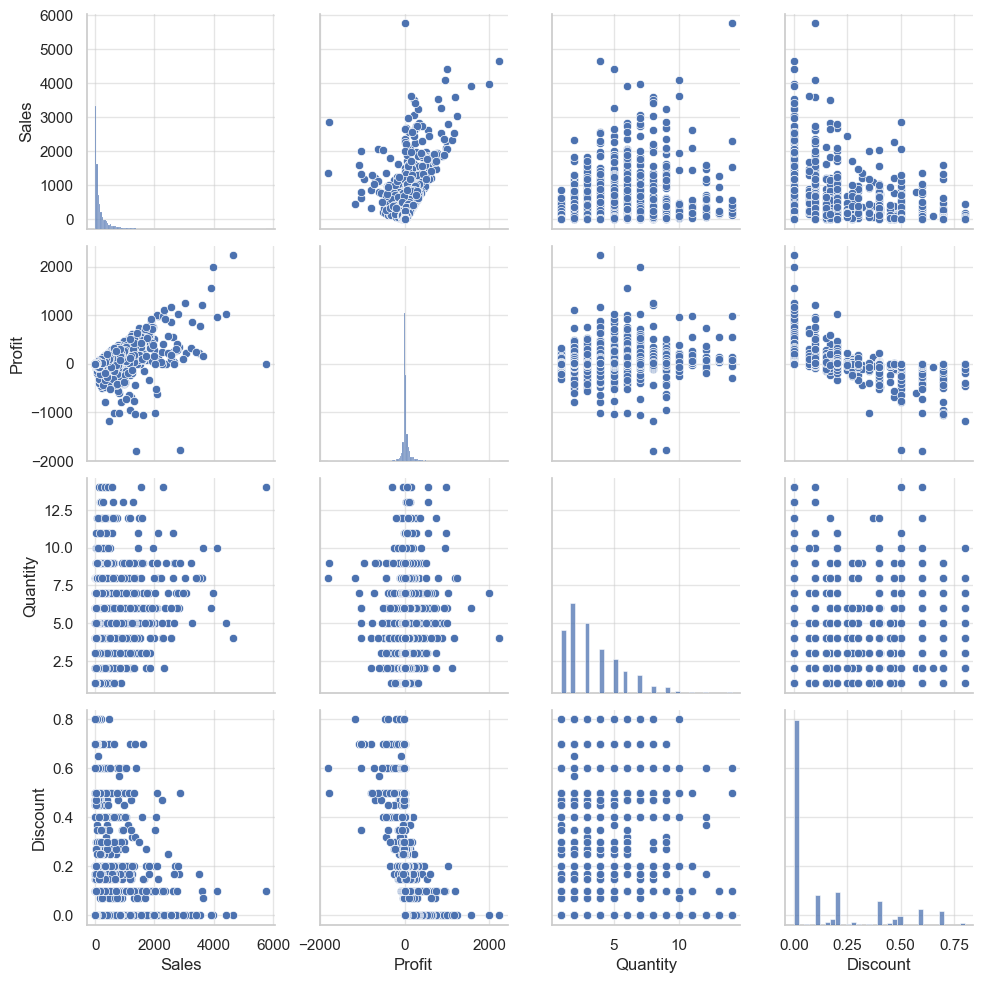

In [4]:
# ==============================
# 1. IMPORTAR LIBRERÍAS
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set(style="whitegrid")

# ==============================
# 2. CARGAR DATASET
# ==============================
df = pd.read_csv('superstore_dataset2012.csv', encoding='latin1')

# Vista inicial
print(df.head())
print(df.info())
print(df.describe())

# ==============================
# 3. LIMPIEZA Y PREPARACIÓN
# ==============================

# Convertir fechas
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed', dayfirst=True)

# Verificar nulos
print(df.isnull().sum())

# ==============================
# 4. VISUALIZACIÓN UNIVARIANTE (MATPLOTLIB)
# ==============================

plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins=30)
plt.title('Distribución de Ventas')
plt.xlabel('Ventas')
plt.ylabel('Frecuencia')
plt.savefig('histograma_ventas.png')  # Guardar imagen
plt.show()

# Conclusión:
# La mayoría de las ventas son bajas, con pocos valores extremadamente altos (distribución sesgada).

# ==============================
# 5. VISUALIZACIÓN UNIVARIANTE (SEABORN)
# ==============================

plt.figure(figsize=(8,5))
sns.boxplot(x='Category', y='Sales', data=df)
plt.title('Distribución de Ventas por Categoría')
plt.show()

# Conclusión:
# Algunas categorías presentan mayor variabilidad y presencia de outliers.

# ==============================
# 6. GRÁFICO BIVARIANTE (MATPLOTLIB)
# ==============================

plt.figure(figsize=(8,5))
plt.scatter(df['Sales'], df['Profit'], alpha=0.5)
plt.title('Ventas vs Beneficio')
plt.xlabel('Ventas')
plt.ylabel('Beneficio')
plt.show()

# Conclusión:
# No siempre mayores ventas implican mayor beneficio; hay ventas con pérdidas.

# ==============================
# 7. GRÁFICO BIVARIANTE (SEABORN)
# ==============================

plt.figure(figsize=(8,5))
sns.regplot(x='Sales', y='Profit', data=df, scatter_kws={'alpha':0.3})
plt.title('Relación entre Ventas y Beneficio (con regresión)')
plt.show()

# Conclusión:
# Existe una leve correlación positiva entre ventas y beneficios.

# ==============================
# 8. VISUALIZACIÓN MULTIVARIANTE (SEABORN)
# ==============================

plt.figure(figsize=(8,6))
correlation = df[['Sales','Profit','Quantity','Discount']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Mapa de correlación')
plt.show()

# Conclusión:
# El descuento tiene correlación negativa con el beneficio.

# ==============================
# 9. SUBPLOTS (MÚLTIPLES GRÁFICOS)
# ==============================

fig, axes = plt.subplots(2, 2, figsize=(12,10))
fig.suptitle('Resumen de Análisis de Ventas', fontsize=16)

# Histograma
axes[0,0].hist(df['Sales'], bins=30)
axes[0,0].set_title('Histograma Ventas')

# Boxplot
sns.boxplot(x='Category', y='Sales', data=df, ax=axes[0,1])
axes[0,1].set_title('Ventas por Categoría')

# Scatter
axes[1,0].scatter(df['Sales'], df['Profit'], alpha=0.5)
axes[1,0].set_title('Ventas vs Beneficio')

# Heatmap
sns.heatmap(correlation, annot=True, cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('Correlación')

plt.tight_layout()
plt.show()

# ==============================
# 10. GRÁFICO ADICIONAL (SEABORN MULTIVARIANTE)
# ==============================

sns.pairplot(df[['Sales','Profit','Quantity','Discount']])
plt.show()

# Conclusión:
# Se observan relaciones entre variables clave, especialmente impacto del descuento.